<h1 style="
  text-align: center;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
  <b> Road Accident Severity Prediction System 🛣️ </b>
</h1>

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Importing Libraries 
</h1>

In [1]:
 pip install folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Loading Dataset
</h1>

In [3]:
df = pd.read_csv(r"C:\Users\LOQ\Downloads\indian_roads_dataset.csv")

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Understanding the Dataset
</h1>

In [4]:
df.shape

(20000, 24)

In [5]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

| Column Name | Description |
|---|---|
| accident_id | Unique ID for each accident |
| city | City where the accident happened |
| state | State where accident occured |
| latitude | North-South geographic coordinate |
| longitude | East-West geographic coordinate |
| date | Date of accident |
| time | Exact accident time |
| hour | Hour extracted from time |
| day_of_week | Day accident occured |
| is_weekend | 1 = Weekend , 0 = Weekday |
|  road_type | Type of road where accident occurred |
| lanes | Number of road lanes (2,4,6) |
| traffic_signal | Whether traffic signals exist |
| weather | Weather condition during accident |
| visibility | Road visibility condition |
| temperature | Temperature during accident |
| traffic_density | Traffic amount on road |
| cause | Reason for accident |
| accident_severity | Severity level of accident |
| vehicles_involved | Number of vehicles in accident |
| casualties | Number of injured or dead people |
| is_peak_hour | Whether accident happened during rush hour|
| festival | Festival/event happening that day |
|risk_score | Calculated risk score |

In [6]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [7]:
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,2024-07-05,23:00,23,Friday,0,...,low,39,high,overspeeding,minor,4,2,0,NaN,0.65


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
  Checking Missing Values
</h1>

In [9]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [10]:
df = df.drop("festival",axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
  Descriptive Statistics
</h1>

In [12]:
df.describe(include = 'object')

,city,state,date,time,day_of_week,road_type,weather,visibility,traffic_density,cause,accident_severity
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,8,7,1201,24,7,3,3,3,3,5,3
top,Chandigarh,Maharashtra,2022-11-03,2:00,Monday,urban,clear,low,low,distraction,minor
freq,2577,5009,30,888,2966,6745,6690,9987,7067,4026,11025


In [13]:
df.describe(include = 'number')

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Numerical Dataframe and Outliers
</h1>

In [14]:
col_num = df.select_dtypes(include = 'number')
col_num

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,18.680827,73.930388,5,1,3,1,32,2,2,0,0.85
1,1,18.817732,72.790846,4,1,4,0,34,4,3,0,0.10
2,2,19.096889,72.819424,13,0,3,0,21,1,1,0,0.45
3,3,30.787805,76.847507,11,1,1,1,30,5,2,0,0.65
4,4,12.965155,80.283313,16,0,3,1,24,2,1,0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,13.092276,77.599571,3,0,1,1,31,3,2,0,0.10
19996,19996,13.172928,80.157062,1,1,1,1,20,4,2,0,0.10
19997,19997,12.997170,80.150724,15,1,3,0,22,3,3,0,0.10
19998,19998,22.454882,88.322213,4,1,3,1,33,1,0,0,0.10


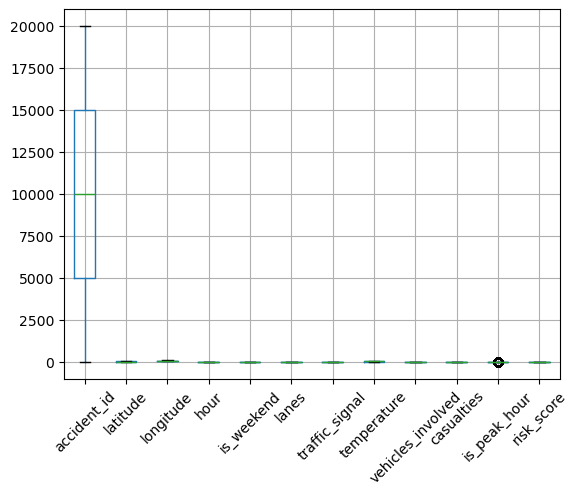

In [15]:
df.boxplot()
plt.xticks(rotation=45)
plt.show()

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Data Dictionary
</h1>

In [16]:
datadict = pd.DataFrame(df.dtypes)
datadict['MissingVal'] = df.isnull().sum()
datadict['Nunique'] = df.nunique()
datadict['Count'] = df.count()
datadict = datadict.rename(columns={0:'DataTypes'})
datadict

,DataTypes,MissingVal,Nunique,Count
accident_id,int64,0,20000,20000
city,object,0,8,20000
state,object,0,7,20000
latitude,float64,0,19907,20000
longitude,float64,0,19927,20000
date,object,0,1201,20000
time,object,0,24,20000
hour,int64,0,24,20000
day_of_week,object,0,7,20000
is_weekend,int64,0,2,20000


<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Group By Analysis
</h1>

### which states need more road safety interventions and funding? 

In [17]:
df.groupby('state')['accident_id'].count().sort_values(ascending = False)

state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
Name: accident_id, dtype: int64

### which urban areas should be prioritized for traffic management improvements?

In [18]:
df.groupby('city')['accident_id'].count().sort_values(ascending = False)

city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: accident_id, dtype: int64

### During which hours should traffic monitoring and emergency services be strengthened?

In [19]:
df.groupby('hour')['accident_id'].count().sort_values(ascending = False)

hour
2     888
13    878
12    866
17    861
1     859
6     856
22    853
8     849
11    841
19    840
0     840
14    838
20    838
21    830
5     827
23    825
3     824
18    823
15    811
4     805
10    789
16    787
9     786
7     786
Name: accident_id, dtype: int64

### How does weather impact accident severity,and when should safety warnings be issued?

In [20]:
df.groupby('weather')['casualties'].mean().sort_values(ascending=False)

weather
rain     1.742699
fog      1.718981
clear    1.717638
Name: casualties, dtype: float64

### which road infrastructures require redesign, maintenance, or additional safety measures?

In [21]:
df.groupby('road_type')['accident_id'].count().sort_values(ascending=False)

road_type
urban      6745
rural      6639
highway    6616
Name: accident_id, dtype: int64

### Which accident causes should be targeted through awareness campaigns and law enforcement?

In [22]:
df.groupby('cause')['accident_id'].count().sort_values(ascending = False)

cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: accident_id, dtype: int64

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Exploratory Data Analysis 
</h1>

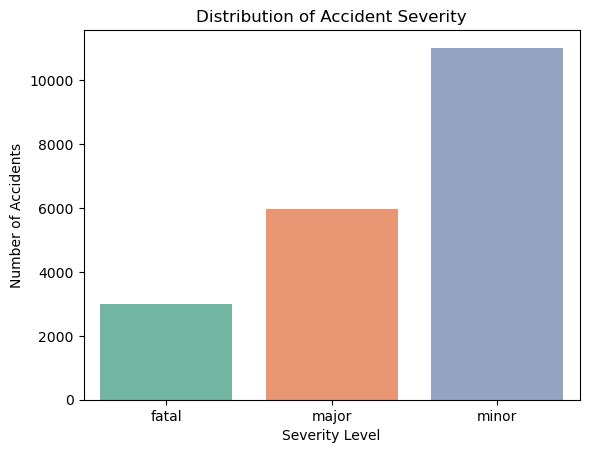

In [23]:
sns.countplot(x ='accident_severity',data=df,palette='Set2')

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()

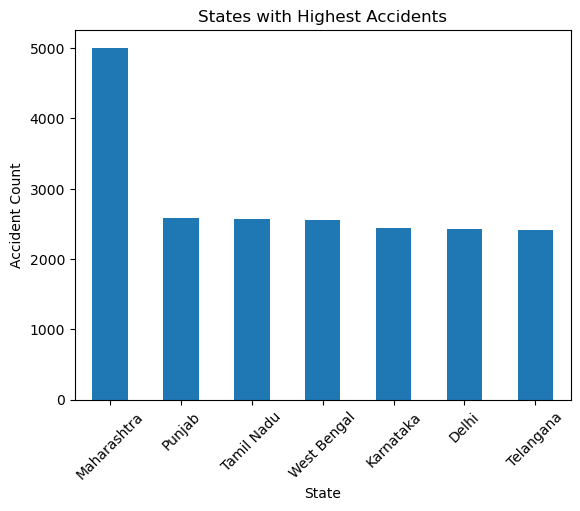

In [24]:
state_accidents = df['state'].value_counts()

state_accidents.plot(kind='bar')

plt.title("States with Highest Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.show()

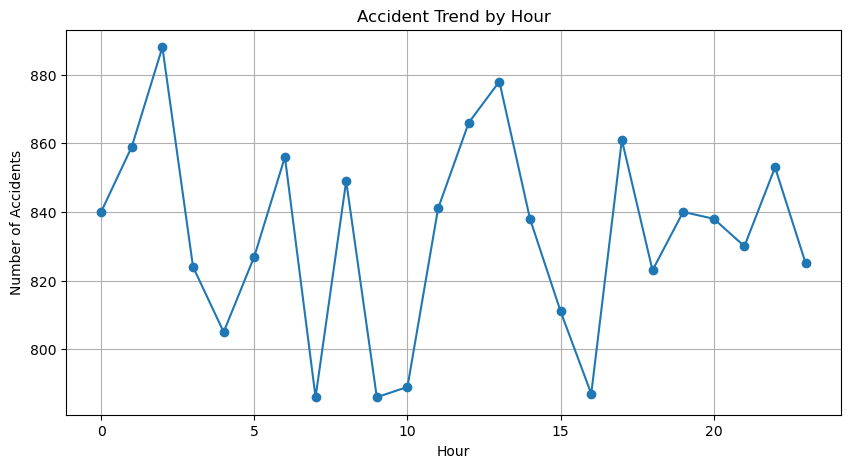

In [25]:
hourly_accidents = df.groupby('hour').size()

plt.figure(figsize=(10,5))

plt.plot(hourly_accidents.index,
         hourly_accidents.values,
         marker='o')

plt.title("Accident Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.show()

In [26]:
from folium.plugins import HeatMap
import folium

#Create base map
m = folium.Map(location=[20.5937, 78.9629],zoom_start=5)

heat_data = df[['latitude','longitude']].dropna().values.tolist()

HeatMap(heat_data).add_to(m)
m

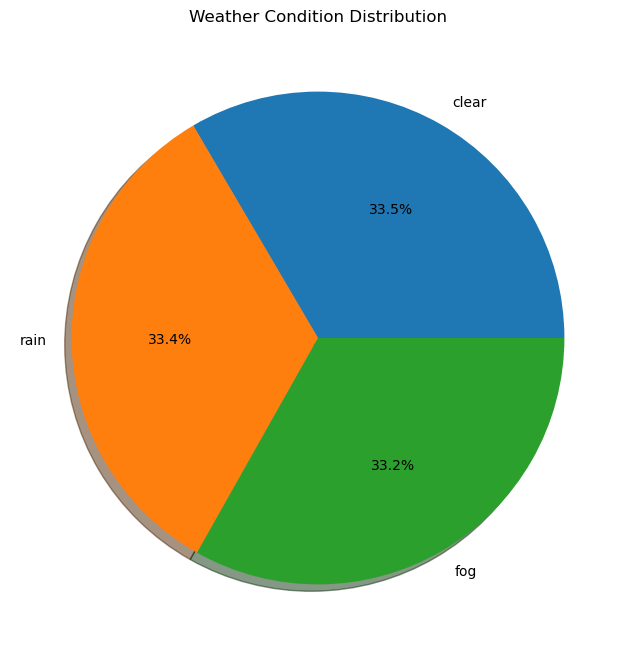

In [27]:
weather_counts = df['weather'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(weather_counts,
        labels = weather_counts.index,
        autopct = '%1.1f%%',
        shadow = True)

plt.title("Weather Condition Distribution")
plt.show()

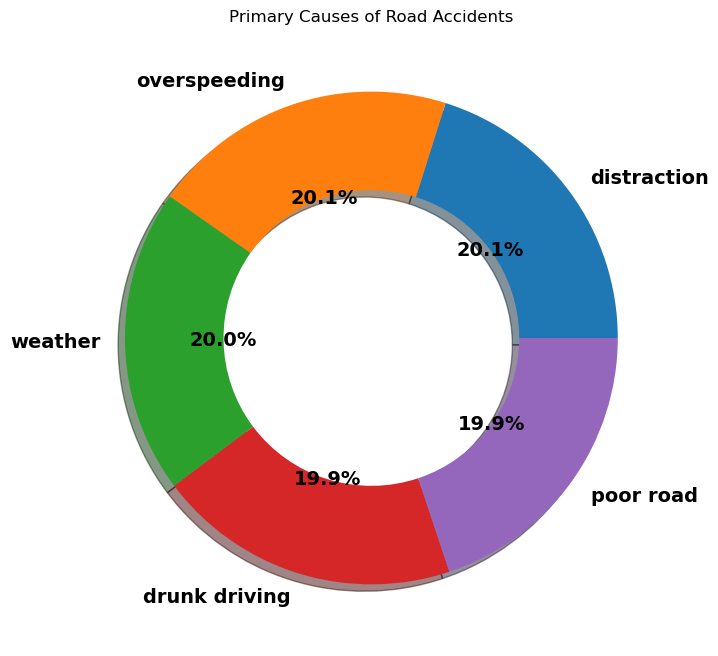

In [28]:
cause_counts = df['cause'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    cause_counts,
    labels=cause_counts.index,
    autopct='%1.1f%%',
    shadow=True,
    wedgeprops={'width':0.4},
    textprops={'fontsize':14,'fontweight':'bold'}
)
plt.title("Primary Causes of Road Accidents")
plt.show()

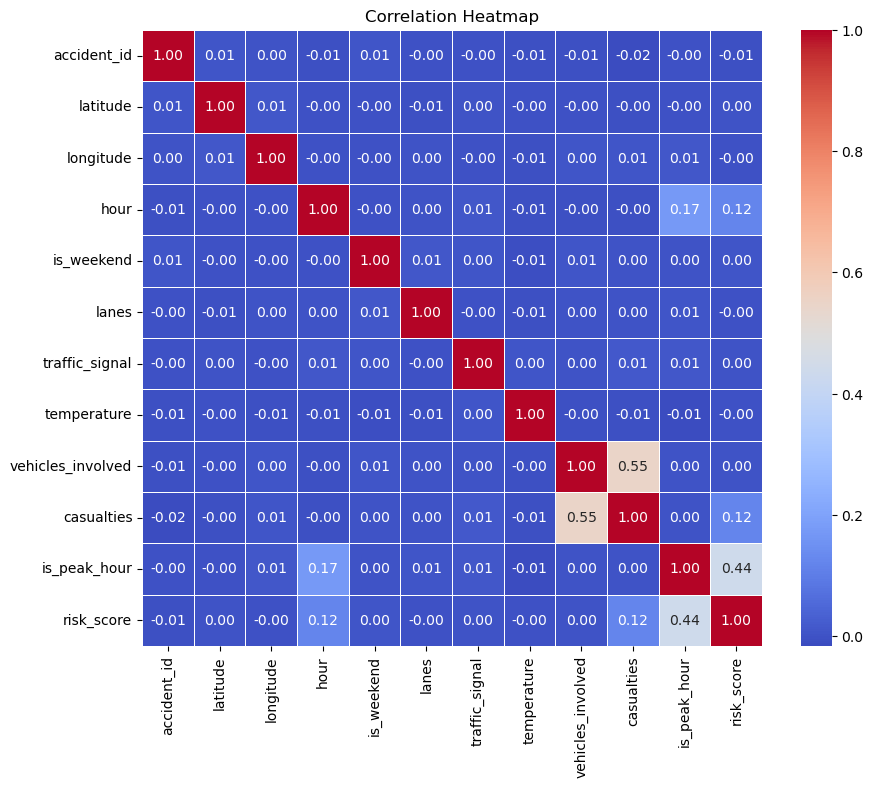

In [29]:
plt.figure(figsize = (10,8))
corr = col_num.corr()

sns.heatmap(
    corr,
    annot = True,
    fmt = ".2f",
    cmap = 'coolwarm',
    linewidths = 0.5
)
plt.title("Correlation Heatmap")
plt.show()

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Feature Engineering
</h1>

In [30]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [31]:
df.drop('accident_id', axis=1, inplace=True)
df.drop('casualties',axis = 1, inplace=True)
df.drop('latitude', axis=1,inplace=True)
df.drop('longitude',axis=1,inplace=True)
df.drop('date',axis=1,inplace=True)
df.drop('time',axis=1,inplace=True)

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Label Encoding
</h1>

In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
cat_cols = df.select_dtypes(include = 'object')

In [34]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Splitting Features and Target
</h1>

In [35]:
x = df.drop('accident_severity',axis=1)
y = df['accident_severity']

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Standard Scaling
</h1>

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Train-Test Split
</h1>

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Machine Learning Models
</h1>

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [40]:
model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = model.predict(x_test)

In [42]:
acc = accuracy_score(y_test,y_pred)
acc

0.55725

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_rf = rf_model.predict(x_test)
acc_rf = accuracy_score(y_test,y_pred_rf)
acc_rf

0.68525

In [47]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.4 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.2 MB/s  0:00:01


In [48]:
import lightgbm as lgb

In [49]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier

In [50]:
model7 = XGBClassifier()
model7.fit(x_train,y_train)
y_pred7 = model7.predict(x_test)
acc7 = accuracy_score(y_test,y_pred7)
acc7

0.66475

In [51]:
model8 = CatBoostClassifier()
model8.fit(x_train,y_train)
y_pred8 = model8.predict(x_test)
acc8 = accuracy_score(y_test,y_pred8)
acc8

Learning rate set to 0.091145
0:	learn: 1.0336966	total: 193ms	remaining: 3m 12s
1:	learn: 0.9824060	total: 200ms	remaining: 1m 39s
2:	learn: 0.9431039	total: 206ms	remaining: 1m 8s
3:	learn: 0.9080683	total: 211ms	remaining: 52.6s
4:	learn: 0.8727299	total: 216ms	remaining: 43s
5:	learn: 0.8514593	total: 222ms	remaining: 36.8s
6:	learn: 0.8332613	total: 228ms	remaining: 32.3s
7:	learn: 0.8131271	total: 234ms	remaining: 29s
8:	learn: 0.7930127	total: 240ms	remaining: 26.4s
9:	learn: 0.7714887	total: 245ms	remaining: 24.3s
10:	learn: 0.7575896	total: 250ms	remaining: 22.5s
11:	learn: 0.7467777	total: 255ms	remaining: 21s
12:	learn: 0.7316646	total: 261ms	remaining: 19.8s
13:	learn: 0.7263022	total: 265ms	remaining: 18.7s
14:	learn: 0.7141904	total: 270ms	remaining: 17.7s
15:	learn: 0.7038742	total: 275ms	remaining: 16.9s
16:	learn: 0.6940594	total: 280ms	remaining: 16.2s
17:	learn: 0.6825022	total: 284ms	remaining: 15.5s
18:	learn: 0.6752108	total: 289ms	remaining: 14.9s
19:	learn: 0.66

0.678

In [52]:
model9 = lgb.LGBMClassifier()
model9.fit(x_train,y_train)
y_pred9 = model9.predict(x_test)
acc9 = accuracy_score(y_test,y_pred9)
acc9

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 145
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 18
[LightGBM] [Info] Start training from score -1.898788
[LightGBM] [Info] Start training from score -1.202308
[LightGBM] [Info] Start training from score -0.598292


0.69325

In [53]:
model10 = GradientBoostingClassifier()
model10.fit(x_train,y_train)

y_pred10 = model10.predict(x_test)

acc10 = accuracy_score(y_test,y_pred10)
acc10

0.70525

In [54]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 20,
    min_samples_split = 5,
    random_state = 42
)

model.fit(x_train,y_train)
accuracy = model.score(x_test,y_test)
print(accuracy)

0.69125


<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
    Model Comparison
</h1>

In [55]:
from tabulate import tabulate
table = [['model','Accuracy'],['Random Forest:',accuracy],
         ['XGBoost:',acc7],['CatBoost:',acc8],['Lightgbm:',acc9],
         ['Gradient Boosting:',acc10]]
print(tabulate(table,headers='firstrow',tablefmt='fancy_grid'))

╒════════════════════╤════════════╕
│ model              │   Accuracy │
╞════════════════════╪════════════╡
│ Random Forest:     │    0.69125 │
├────────────────────┼────────────┤
│ XGBoost:           │    0.66475 │
├────────────────────┼────────────┤
│ CatBoost:          │    0.678   │
├────────────────────┼────────────┤
│ Lightgbm:          │    0.69325 │
├────────────────────┼────────────┤
│ Gradient Boosting: │    0.70525 │
╘════════════════════╧════════════╛


In [56]:
model

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
arr = x.iloc[0].tolist()
print(arr)

[7.0, 2.0, 5.0, 3.0, 1.0, 0.0, 3.0, 1.0, 1.0, 1.0, 32.0, 0.0, 4.0, 2.0, 0.0, 0.85, 10.0, 2023.0]


In [58]:
new = [[7.0, 2.0, 5.0, 3.0, 1.0, 0.0, 3.0, 1.0, 1.0, 1.0, 32.0, 0.0, 4.0, 2.0, 0.0, 0.85, 10.0, 2023.0]]

In [59]:
prediction = model.predict(new)
prediction

array([0])

In [60]:
arr1 = x.iloc[1].tolist()
print(arr1)

[6.0, 2.0, 4.0, 3.0, 1.0, 2.0, 4.0, 0.0, 0.0, 0.0, 34.0, 1.0, 4.0, 4.0, 0.0, 0.1, 5.0, 2023.0]


In [61]:
nd = [[6.0, 2.0, 4.0, 3.0, 1.0, 2.0, 4.0, 0.0, 0.0, 0.0, 34.0, 1.0, 4.0, 4.0, 0.0, 0.1, 5.0, 2023.0]]

In [62]:
pred = model.predict(nd)
pred

array([1])

In [63]:
arr2 = x.iloc[2].tolist()
print(arr2)

[6.0, 2.0, 13.0, 6.0, 0.0, 2.0, 3.0, 0.0, 1.0, 1.0, 21.0, 2.0, 4.0, 1.0, 0.0, 0.45, 7.0, 2024.0]


In [64]:
n = [[6.0, 2.0, 13.0, 6.0, 0.0, 2.0, 3.0, 0.0, 1.0, 1.0, 21.0, 2.0, 4.0, 1.0, 0.0, 0.45, 7.0, 2024.0]]

In [65]:
p = model.predict(n)
p

array([2])

In [66]:
y

0        0
1        1
2        2
3        2
4        2
        ..
19995    2
19996    1
19997    2
19998    2
19999    2
Name: accident_severity, Length: 20000, dtype: int64

In [67]:
df['accident_severity'].value_counts()

accident_severity
2    11025
1     5988
0     2987
Name: count, dtype: int64

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Classification Report
</h1>

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       591
           1       1.00      0.00      0.00      1180
           2       0.65      1.00      0.79      2229

    accuracy                           0.71      4000
   macro avg       0.88      0.67      0.60      4000
weighted avg       0.81      0.71      0.59      4000



<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Confusion Matrix
</h1>

In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred10)
print(cm)

[[ 591    0    0]
 [   1    1 1178]
 [   0    0 2229]]


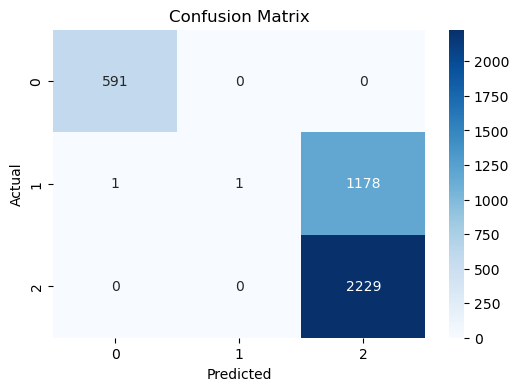

In [70]:






















from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred10)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h1 style="
  text-align: left;
  padding: 18px 30px;
  margin: 30px auto;
  width: fit-content;
  background: linear-gradient(135deg, #ffffff, #87CEEB);
  color: #0D47A1;
  border-radius: 12px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0px 10px 25px rgba(0, 0, 0, 0.4);
">
   Feature Importance
</h1>

In [71]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model10.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

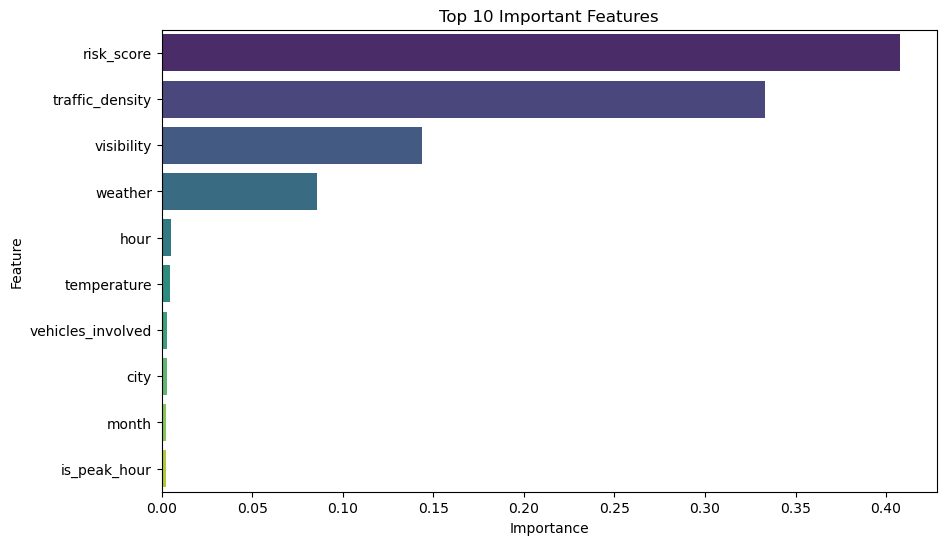

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10),
    palette='viridis'
)

plt.title("Top 10 Important Features")

plt.show()